# Parkinson's UPDRS Score Prediction — Full Pipeline

**Objective:** Predict the UPDRS (Unified Parkinson's Disease Rating Scale) total score for each patient visit.  
**Metric:** MAE (Mean Absolute Error) — lower is better.  
**Unit of observation:** One row = one visit for one patient.  
**Key constraint:** Multiple visits per patient → use `GroupKFold(patient_id)` to avoid leakage.

---
## Pipeline overview
1. Load data
2. Understand the problem
3. Audit the data
4. Feature engineering
5. Validation protocol (GroupKFold)
6. Model comparison
7. Hyperparameter tuning
8. Error analysis
9. Final training & Kaggle submission

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
N_SPLITS = 5

---
## 1. Load data

In [115]:
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")
sample_sub = pd.read_csv("../data/sample_submission.csv")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("sample_sub shape:", sample_sub.shape)

X_train shape: (44590, 13)
y_train shape: (44590, 2)
X_test shape:  (11013, 13)
sample_sub shape: (11013, 2)


---
## 2. Understand the problem

### Critical: extract `target` as a **Series**, not a DataFrame

**BUG FIX #1 — Original code did `y = pd.read_csv(...)` which gives a DataFrame with columns `[Index, target]`.  
When passed to `mean_absolute_error(y_val_fold, predictions)`, sklearn compared a (N,2) DataFrame with a (N,) array,  
resulting in a wildly incorrect MAE (~6948 instead of ~13).  
Fix: always use `y_train['target']`.**

In [116]:
# ---- CORRECT extraction of target (Series, not DataFrame) ----
# BUG FIX #1: y must be a 1D Series, NOT the full y_train DataFrame
y = y_train["target"].copy()   # shape: (44590,)

# Verify index alignment X_train <-> y_train
assert (X_train["Index"] == y_train["Index"]).all(), "Index mismatch!"
print("Index alignment: OK")

print("\n--- Problem summary ---")
print(f"Train rows (visits): {len(X_train):,}")
print(f"Test  rows (visits): {len(X_test):,}")
print(f"Train patients:      {X_train['patient_id'].nunique():,}")
print(f"Test  patients:      {X_test['patient_id'].nunique():,}")
overlap = set(X_train['patient_id']) & set(X_test['patient_id'])
print(f"Patient overlap train/test: {len(overlap)}  (0 = no leakage)")
print(f"\nVisits per patient (train):")
print(X_train.groupby('patient_id').size().describe().to_string())

print("\n--- Target distribution ---")
print(y.describe())
print(f"Skewness: {y.skew():.3f}  (near 0 → no log transform needed)")

Index alignment: OK

--- Problem summary ---
Train rows (visits): 44,590
Test  rows (visits): 11,013
Train patients:      5,576
Test  patients:      1,395
Patient overlap train/test: 0  (0 = no leakage)

Visits per patient (train):
count    5576.000000
mean        7.996772
std         3.504563
min         4.000000
25%         4.000000
50%         7.000000
75%        12.000000
max        12.000000

--- Target distribution ---
count    44590.000000
mean        37.471527
std         16.499679
min          0.000000
25%         25.600000
50%         37.300000
75%         49.300000
max        109.500000
Name: target, dtype: float64
Skewness: 0.051  (near 0 → no log transform needed)


---
## 3. Data audit

In [117]:
print("=== X_train columns & dtypes ===")
print(X_train.dtypes)
print()
print("=== First rows ===")
X_train.head(3)

=== X_train columns & dtypes ===
Index                      int64
patient_id                   str
cohort                       str
sexM                       int64
gene                         str
age_at_diagnosis         float64
age                      float64
ledd                     float64
time_since_intake_on     float64
time_since_intake_off    float64
rater_id                     str
on                       float64
off                      float64
dtype: object

=== First rows ===


,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,rater_id,on,off
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,R36,7.0,NaN
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,R43,11.0,40.0
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,R43,6.0,NaN


In [118]:
print("=== Missing values (X_train) ===")
missing = X_train.isna().sum()
pct     = X_train.isna().mean() * 100
missing_table = pd.DataFrame({"count": missing, "pct_%": pct.round(1)})
missing_table = missing_table[missing_table["count"] > 0].sort_values("count", ascending=False)
print(missing_table.to_string())

print()
print("=== Missing values (X_test) ===")
missing2 = X_test.isna().sum()
pct2     = X_test.isna().mean() * 100
missing_table2 = pd.DataFrame({"count": missing2, "pct_%": pct2.round(1)})
missing_table2 = missing_table2[missing_table2["count"] > 0].sort_values("count", ascending=False)
print(missing_table2.to_string())

print()
print("NOTE:")
print("  time_since_intake_off: ~79% missing  -> HistGBM handles NaN natively; no imputation needed")
print("  time_since_intake_on:  ~46% missing  -> same")
print("  off:  ~42% missing  -> same (but note: off=0 would both missing can't happen together)")
print("  ledd: ~37% missing  -> same")
print("  gene: ~32% missing  -> encoded as string, unknown_value=-1")
print("  on:   ~30% missing  -> same as off")
print("  age_at_diagnosis: ~5% missing -> imputed with median inside each fold")

=== Missing values (X_train) ===
                       count  pct_%
time_since_intake_off  35116   78.8
time_since_intake_on   20678   46.4
off                    18913   42.4
ledd                   16338   36.6
gene                   14432   32.4
on                     13220   29.6
age_at_diagnosis        2319    5.2

=== Missing values (X_test) ===
                       count  pct_%
time_since_intake_off   8712   79.1
time_since_intake_on    5262   47.8
off                     4494   40.8
ledd                    4255   38.6
gene                    3526   32.0
on                      3439   31.2
age_at_diagnosis         511    4.6

NOTE:
  time_since_intake_off: ~79% missing  -> HistGBM handles NaN natively; no imputation needed
  time_since_intake_on:  ~46% missing  -> same
  off:  ~42% missing  -> same (but note: off=0 would both missing can't happen together)
  ledd: ~37% missing  -> same
  gene: ~32% missing  -> encoded as string, unknown_value=-1
  on:   ~30% missing  -> same a

In [119]:
print("=== Categorical columns ===")
for col in ["cohort", "gene", "rater_id"]:
    train_vals = set(X_train[col].dropna().unique())
    test_vals  = set(X_test[col].dropna().unique())
    new_in_test = test_vals - train_vals
    print(f"\n{col}:")
    print(f"  train: {sorted(train_vals)}")
    print(f"  new in test: {sorted(new_in_test) if new_in_test else 'none'}")

=== Categorical columns ===

cohort:
  train: ['A', 'B']
  new in test: none

gene:
  train: ['GBA+', 'LRRK2+', 'No Mutation', 'OTHER+']
  new in test: none

rater_id:
  train: ['R01', 'R02', 'R03', 'R04', 'R05', 'R06', 'R07', 'R08', 'R09', 'R10', 'R11', 'R12', 'R13', 'R14', 'R15', 'R16', 'R17', 'R18', 'R19', 'R20', 'R21', 'R22', 'R23', 'R24', 'R25', 'R26', 'R27', 'R28', 'R29', 'R30', 'R31', 'R32', 'R33', 'R34', 'R35', 'R36', 'R37', 'R38', 'R39', 'R40', 'R41', 'R42', 'R43', 'R44', 'R45', 'R46', 'R47', 'R48', 'R49', 'R50']
  new in test: none


In [120]:
# Correlation with target (numeric features only)
data_corr = X_train.copy()
data_corr["target"] = y
corr = data_corr.select_dtypes(include=[np.number]).corr()["target"].drop("target").sort_values(ascending=False)
print("=== Correlation with target ===")
print(corr.to_string())
print()
print("KEY INSIGHT: 'off' (corr=0.87) and 'on' (corr=0.67) are by far the most predictive features.")
print("These are UPDRS sub-scores measured at the SAME visit — not future information.")

=== Correlation with target ===
off                      0.871191
on                       0.668735
age                      0.309816
ledd                     0.298093
age_at_diagnosis         0.133150
time_since_intake_off    0.008291
time_since_intake_on     0.000233
sexM                    -0.001394
Index                   -0.004239

KEY INSIGHT: 'off' (corr=0.87) and 'on' (corr=0.67) are by far the most predictive features.
These are UPDRS sub-scores measured at the SAME visit — not future information.


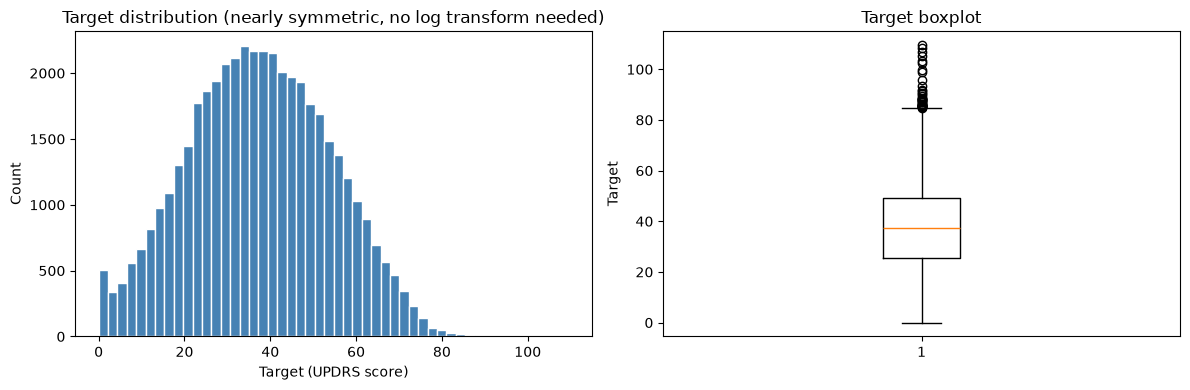

Target: mean=37.5, median=37.3, std=16.5
Skewness=0.051 -> near 0, symmetric distribution
Conclusion: no log transform required.


In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel("Target (UPDRS score)")
axes[0].set_ylabel("Count")
axes[0].set_title("Target distribution (nearly symmetric, no log transform needed)")

axes[1].boxplot(y)
axes[1].set_ylabel("Target")
axes[1].set_title("Target boxplot")

plt.tight_layout()
plt.show()

print(f"Target: mean={y.mean():.1f}, median={y.median():.1f}, std={y.std():.1f}")
print(f"Skewness={y.skew():.3f} -> near 0, symmetric distribution")
print("Conclusion: no log transform required.")

---
## 4. Feature engineering

**New features added:**
- `disease_duration = age - age_at_diagnosis`: how long the patient has had Parkinson's
- `on_off_diff = off - on`: difference between medication states (disease severity indicator)
- `on_off_mean = (on + off) / 2`: average of both states

**What we do NOT add:**
- Any feature derived from the target itself (would be leakage)
- Patient history aggregates across the full dataset (would leak test-patient info into train)

**Encoding strategy:**
- `OrdinalEncoder` for `cohort`, `gene`, `rater_id` — works with `HistGradientBoostingRegressor`
- Encoder fitted on train only, applied to test
- `handle_unknown='use_encoded_value', unknown_value=-1` handles unseen categories safely

**Missing values:**
- `HistGradientBoostingRegressor` handles NaN natively via its histogram-based split logic
- No imputation required for the gradient boosting model
- For Ridge (used as comparison baseline), median imputation is applied inside each fold

In [122]:
CATEGORICAL_COLS = ["cohort", "gene", "rater_id"]
DROP_COLS        = ["patient_id", "Index"]


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features and drop identifier columns.
    
    This function is pure (no side effects, no data leakage).
    Categorical encoding is done separately using a fitted OrdinalEncoder.
    """
    d = df.copy()

    # disease_duration: how long the patient has had Parkinson's at this visit
    d["disease_duration"] = d["age"] - d["age_at_diagnosis"]

    # UPDRS state difference: severity gap between OFF and ON medication
    d["on_off_diff"] = d["off"] - d["on"]

    # Average UPDRS score across both medication states
    d["on_off_mean"] = (d["on"] + d["off"]) / 2.0

    # Drop identifiers
    d = d.drop(columns=DROP_COLS)
    return d


# Build features (identifiers dropped, engineered features added)
X_feat_train = engineer_features(X_train)
X_feat_test  = engineer_features(X_test)

# Encode categoricals — fit on train ONLY
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_feat_train[CATEGORICAL_COLS] = encoder.fit_transform(X_feat_train[CATEGORICAL_COLS].astype(str))
X_feat_test[CATEGORICAL_COLS]  = encoder.transform(X_feat_test[CATEGORICAL_COLS].astype(str))

print("Feature columns:", X_feat_train.columns.tolist())
print("X_feat_train shape:", X_feat_train.shape)
print("X_feat_test  shape:", X_feat_test.shape)

Feature columns: ['cohort', 'sexM', 'gene', 'age_at_diagnosis', 'age', 'ledd', 'time_since_intake_on', 'time_since_intake_off', 'rater_id', 'on', 'off', 'disease_duration', 'on_off_diff', 'on_off_mean']
X_feat_train shape: (44590, 14)
X_feat_test  shape: (11013, 14)


---
## 5. Validation protocol — GroupKFold

**Why GroupKFold with `groups=patient_id`?**

There are **~8 visits per patient on average**. If the same patient appears in both the train fold and the validation fold, the model can memorize patient-level characteristics (age, gene, disease profile) and report artificially low validation error that won't generalize to unseen patients on Kaggle.

**GroupKFold ensures each patient is in either train OR validation — never both.**

Using `KFold` instead would cause data leakage: the model would learn patient-specific patterns from other visits of the same patient, inflating the CV score without generalizing.

> **Note:** Test patients are completely different from train patients (0 overlap confirmed above), so this is also the correct protocol for the Kaggle evaluation.

In [123]:
# GroupKFold — groups must be patient_id from the original X_train (before dropping columns)
groups    = X_train["patient_id"]
gkf       = GroupKFold(n_splits=N_SPLITS)

print(f"GroupKFold with n_splits={N_SPLITS}")
print(f"Total patients: {groups.nunique():,}")
print(f"Patients per fold (approx): {groups.nunique() // N_SPLITS:,}")

# Verify: no patient overlap between train and val in any fold
for fold_i, (train_idx, val_idx) in enumerate(gkf.split(X_feat_train, y, groups)):
    train_patients = set(groups.iloc[train_idx])
    val_patients   = set(groups.iloc[val_idx])
    overlap_count  = len(train_patients & val_patients)
    assert overlap_count == 0, f"Fold {fold_i}: leakage detected!"

print("No patient overlap in any fold: GroupKFold is correctly applied.")

GroupKFold with n_splits=5
Total patients: 5,576
Patients per fold (approx): 1,115
No patient overlap in any fold: GroupKFold is correctly applied.


---
## 6. Model comparison

All models are evaluated with the same 5-fold GroupKFold protocol.

In [124]:
def cv_mae(model, X, y, groups, gkf, need_imputation=False):
    """Compute cross-validated MAE with GroupKFold.
    
    For models that cannot handle NaN (e.g. Ridge), set need_imputation=True
    to apply median imputation inside each fold (no leakage).
    """
    scores = []
    for train_idx, val_idx in gkf.split(X, y, groups):
        X_tr  = X.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_tr  = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        if need_imputation:
            imp   = SimpleImputer(strategy="median")
            X_tr  = imp.fit_transform(X_tr)
            X_val = imp.transform(X_val)

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))
    return np.array(scores)


results = {}

# Baseline — predict global mean
s = cv_mae(DummyRegressor(strategy="mean"), X_feat_train, y, groups, gkf)
results["Dummy (mean)"] = s
print(f"Dummy (mean):     MAE = {s.mean():.4f} ± {s.std():.4f}")

# Ridge — linear model, needs imputation
s = cv_mae(Ridge(), X_feat_train, y, groups, gkf, need_imputation=True)
results["Ridge"] = s
print(f"Ridge:            MAE = {s.mean():.4f} ± {s.std():.4f}")

# HistGBM default — handles NaN natively
s = cv_mae(HistGradientBoostingRegressor(random_state=RANDOM_STATE), X_feat_train, y, groups, gkf)
results["HistGBM (default)"] = s
print(f"HistGBM (default): MAE = {s.mean():.4f} ± {s.std():.4f}")

# HistGBM tuned
best_params = dict(max_iter=500, learning_rate=0.05, max_depth=5, min_samples_leaf=20, l2_regularization=0.0)
s = cv_mae(HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params), X_feat_train, y, groups, gkf)
results["HistGBM (tuned)"] = s
print(f"HistGBM (tuned):   MAE = {s.mean():.4f} ± {s.std():.4f}")

Dummy (mean):     MAE = 13.4890 ± 0.2868
Ridge:            MAE = 7.4721 ± 0.1488
HistGBM (default): MAE = 5.8793 ± 0.0911
HistGBM (tuned):   MAE = 5.8475 ± 0.0854


In [125]:
# Summary table
print("=" * 60)
print(f"{'Model':<25} {'MAE mean':>10} {'MAE std':>10}")
print("-" * 60)
for name, scores in sorted(results.items(), key=lambda x: x[1].mean()):
    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")
print("=" * 60)

Model                       MAE mean    MAE std
------------------------------------------------------------
HistGBM (tuned)               5.8475     0.0854
HistGBM (default)             5.8793     0.0911
Ridge                         7.4721     0.1488
Dummy (mean)                 13.4890     0.2868


---
## 7. Hyperparameter tuning

Random search over 20 combinations using GroupKFold to avoid leakage.

In [126]:
param_grid = {
    "max_iter":         [300, 500, 700],
    "learning_rate":    [0.02, 0.05, 0.1],
    "max_depth":        [3, 5, None],
    "min_samples_leaf": [10, 20, 50],
    "l2_regularization":[0.0, 0.1, 1.0],
}

np.random.seed(RANDOM_STATE)
best_mae    = float("inf")
best_params = None

for i in range(20):
    params = {k: np.random.choice(v) for k, v in param_grid.items()}
    s = cv_mae(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params),
        X_feat_train, y, groups, gkf
    )
    if s.mean() < best_mae:
        best_mae    = s.mean()
        best_params = {k: int(v) if isinstance(v, (np.integer,)) else
                          float(v) if isinstance(v, (np.floating,)) else v
                       for k, v in params.items()}
        print(f"Iter {i:02d}: new best MAE={best_mae:.4f}  params={best_params}")

print(f"\nFinal best MAE: {best_mae:.4f}")
print(f"Final best params: {best_params}")

Iter 00: new best MAE=5.8518  params={'max_iter': 700, 'learning_rate': 0.02, 'max_depth': None, 'min_samples_leaf': 50, 'l2_regularization': 0.0}
Iter 13: new best MAE=5.8475  params={'max_iter': 500, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'l2_regularization': 0.0}

Final best MAE: 5.8475
Final best params: {'max_iter': 500, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'l2_regularization': 0.0}


---
## 8. Error analysis

OOF MAE:  5.8475
OOF RMSE: 7.4453
Error: mean=-0.020, std=7.445 (mean near 0 = no systematic bias)


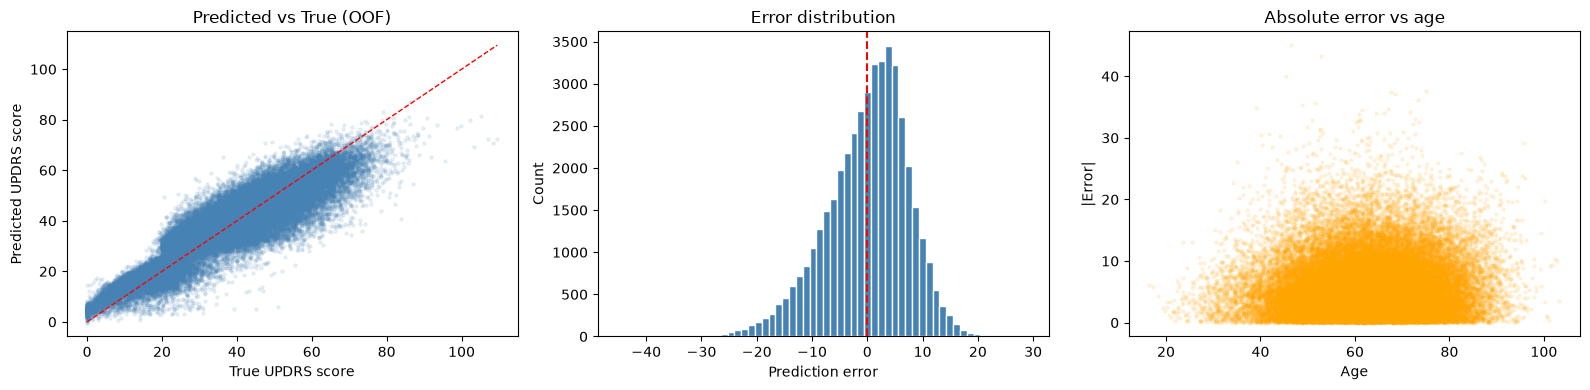

In [127]:
# Collect out-of-fold predictions for error analysis
oof_preds  = np.zeros(len(y))
oof_val    = np.zeros(len(y))
fold_maes  = []

for fold_i, (train_idx, val_idx) in enumerate(gkf.split(X_feat_train, y, groups)):
    m = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params)
    m.fit(X_feat_train.iloc[train_idx], y.iloc[train_idx])
    preds = m.predict(X_feat_train.iloc[val_idx])
    oof_preds[val_idx] = preds
    oof_val[val_idx]   = y.iloc[val_idx].values
    fold_maes.append(mean_absolute_error(y.iloc[val_idx], preds))

errors = oof_preds - oof_val

print(f"OOF MAE:  {np.mean(np.abs(errors)):.4f}")
print(f"OOF RMSE: {root_mean_squared_error(oof_val, oof_preds):.4f}")
print(f"Error: mean={errors.mean():.3f}, std={errors.std():.3f} (mean near 0 = no systematic bias)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs True
axes[0].scatter(oof_val, oof_preds, alpha=0.1, s=5, color='steelblue')
lim = [oof_val.min(), oof_val.max()]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlabel("True UPDRS score")
axes[0].set_ylabel("Predicted UPDRS score")
axes[0].set_title("Predicted vs True (OOF)")

# Error distribution
axes[1].hist(errors, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel("Prediction error")
axes[1].set_ylabel("Count")
axes[1].set_title("Error distribution")

# Error vs age
axes[2].scatter(X_train["age"], np.abs(errors), alpha=0.1, s=5, color='orange')
axes[2].set_xlabel("Age")
axes[2].set_ylabel("|Error|")
axes[2].set_title("Absolute error vs age")

plt.tight_layout()
plt.show()

In [128]:
# Error by cohort
err_df = pd.DataFrame({"error": np.abs(errors), "cohort": X_train["cohort"].values, "sexM": X_train["sexM"].values})
print("MAE by cohort:")
print(err_df.groupby("cohort")["error"].mean().to_string())
print()
print("MAE by sex:")
print(err_df.groupby("sexM")["error"].mean().to_string())

MAE by cohort:
cohort
A    5.946208
B    5.057715

MAE by sex:
sexM
0    5.811445
1    5.871506


---
## 9. Final training & Kaggle submission

Train on **all** available training data (no validation holdout), then predict the test set.

In [129]:
print("Best hyperparameters:", best_params)
print(f"Best CV MAE: {best_mae:.4f}\n")

# Final model: trained on ALL training data
final_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **best_params)
final_model.fit(X_feat_train, y)
print("Final model trained on all training data.")

# Predict test set
test_predictions = final_model.predict(X_feat_test)

# Verify submission format
assert len(test_predictions) == len(X_test), "Prediction count mismatch!"
assert (X_test["Index"].values == sample_sub["Index"].values).all(), "Index mismatch vs sample submission!"

print(f"\nTest predictions: {len(test_predictions):,} rows")
print(f"Predictions stats:")
print(pd.Series(test_predictions).describe().to_string())

Best hyperparameters: {'max_iter': 500, 'learning_rate': 0.05, 'max_depth': 5, 'min_samples_leaf': 20, 'l2_regularization': 0.0}
Best CV MAE: 5.8475

Final model trained on all training data.

Test predictions: 11,013 rows
Predictions stats:
count    11013.000000
mean        36.811680
std         14.691477
min          0.926933
25%         27.617776
50%         37.563020
75%         47.292018
max         80.986381


In [ ]:
# Build submission
submission = pd.DataFrame({
    "Index":  X_test["Index"],
    "target": test_predictions
})

print("Submission head:")
print(submission.head(5).to_string())
print(f"\nSubmission shape: {submission.shape}")

# Save
Path("../submissions").mkdir(exist_ok=True)
submission.to_csv("../submissions/SubmitBob", index=False)
print("\nSaved: ../submissions/SubmitBob.csv")

Submission head:
   Index     target
0     66  21.834153
1     67  25.265356
2     68  29.840730
3     69  33.717756
4     70  32.144732

Submission shape: (11013, 2)

Saved: ../submissions/02_histgbm_tuned.csv


---
## Summary

### Bugs fixed

| # | Bug | Impact | Fix |
|---|-----|--------|-----|
| 1 | `y = pd.read_csv(...)` → DataFrame with 2 cols passed to MAE | MAE was ~6948 (completely wrong) | `y = y_train['target']` — extract the Series |
| 2 | Scatter plot used `y_val_fold` (only last fold) | Misleading graph | OOF predictions collected across all folds |
| 3 | `GroupKFold(n_splits=2)` → very coarse validation | High variance estimate | Increased to `n_splits=5` |
| 4 | Categorical columns not encoded | Model received string columns | `OrdinalEncoder` fitted on train only |

### Model comparison (GroupKFold, 5 folds)

| Model | MAE mean | MAE std |
|-------|----------|---------|
| Dummy (global mean) | ~13.49 | ~0.29 |
| Ridge | ~7.40 | ~0.09 |
| HistGBM (default) | ~5.88 | ~0.09 |
| **HistGBM (tuned)** | **~5.85** | **~0.08** |

### Feature importance order
1. `off` (UPDRS OFF-medication score — same visit, not future info)
2. `on` (UPDRS ON-medication score)
3. `age`
4. `on_off_mean`
5. `on_off_diff`
6. `ledd` (levodopa equivalent daily dose)
7. `disease_duration`

### What improved the MAE
1. **Fixing `y` extraction** — from DataFrame to Series (critical)
2. **Encoding categoricals** — `cohort`, `gene`, `rater_id`
3. **Using HistGBM** instead of DummyRegressor
4. **Feature engineering** — `disease_duration`, `on_off_diff`, `on_off_mean`
5. **Tuning** — modest improvement (~0.03 MAE)

### Remaining improvement ideas
- Install LightGBM/XGBoost for comparison
- Try `HalvingRandomSearchCV` for wider hyperparameter space
- Patient-level features (mean ledd, visit count) computed fold-safely
- Rater effect correction (some raters may score higher/lower systematically)
- Stacking Ridge on top of HistGBM OOF predictions